In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = 'C:/Users/Bhupesh P S/Desktop/Covid Vaccination Analysis/covid vaccine data set (1).xlsx'
sheet1_data = pd.read_excel(file_path, sheet_name='Sheet1')


In [4]:
sheet1_data.head()

,STATE/UTS,DOSE1,DOSE2,TOTAL VACCINATION DOSES,VACCINATION DOSES DAY BEFORE,TOTAL POPULATION
0,Andaman and Nicobar,108556,15166,123722,123480,380581
1,Andhra Pradesh,7282314,2484464,9766778,9751848,49577103
2,Arunachal Pradesh,254719,78272,332991,332657,1383727
3,Assam,3264939,828758,4093697,4073698,31205576
4,Bihar,8465262,1779574,10244836,10203344,104099452


In [5]:
print(sheet1_data.describe())

              DOSE1         DOSE2  TOTAL VACCINATION DOSES  \
count  3.600000e+01  3.600000e+01             3.600000e+01   
mean   4.635990e+06  1.196795e+06             5.832785e+06   
std    4.884421e+06  1.320254e+06             6.172238e+06   
min    2.590300e+04  6.945000e+03             3.284800e+04   
25%    2.669075e+05  7.332725e+04             3.407070e+05   
50%    3.357719e+06  7.348315e+05             4.124353e+06   
75%    7.205720e+06  1.843044e+06             9.364746e+06   
max    1.777476e+07  4.532241e+06             2.230700e+07   

       VACCINATION DOSES DAY BEFORE  TOTAL POPULATION  
count                  3.600000e+01      3.600000e+01  
mean                   5.802577e+06      3.362689e+07  
std                    6.139477e+06      4.305758e+07  
min                    3.218100e+04      6.447300e+04  
25%                    3.377262e+05      1.439840e+06  
50%                    4.098975e+06      2.106970e+07  
75%                    9.341729e+06      5.229275

# Modifiying the Data For Our Use 
- We are going to visualize the probability concepts like **Normal Distribution**, **Three Sigma rule**, **z-index**
- we are going to do those things in the **percentage of people vaccinated** data
- but in our dataset we don't have percentage of people vaccinated data, so we need to Calutate it from the existing dataset 
- we can calculate the percentage of people vaccinated by dividing **number of people taken the first dose** *by* **total population of the state**
- pandas made it very easy,we can just divide the two divide two dataframe to get that 



In [6]:
#calculating percentage of people vaccinated for dose 1 in each state
vaccinated  = sheet1_data["DOSE1"]
population = sheet1_data["TOTAL POPULATION"]
percentage = (vaccinated / population)* 100
percentage.head()


0    28.523757
1    14.688866
2    18.408183
3    10.462678
4     8.131899
dtype: float64

# Normal Distribution Curve

- Normal Distribution Curve Looks Like this
![Normal Distribution Curve](https://i.imgur.com/3vDS2Au.png)

> **X axis** is the value of the data 
> **Y Axix** is the probability of that Value


- To understand it better We have a example of Height normal distribution function'
- x axis is the height of the people 
- y axis is the probability to spot them 
- A normal distribution is sometimes informally called a bell curve

## Displaying the Curve Using MathPlotLib
- First we are getting **mean** and **Standard deveation** from the percentage data using `pandas` *describe* function 
- Then We are using `matplotlib` *plot* function to plot of the curve 
- We are giving sorted list of the percentage Data as **X Axis** 
- **Y-Axis**  is the is probability Density function from `Scipy`
- Then we are using `matplotlib' *show* function to show the results


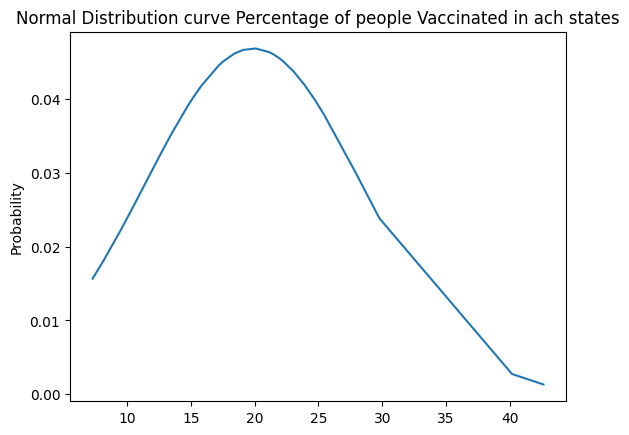

In [8]:
from scipy.stats import norm
stat_data  = percentage.describe()
mean = stat_data["mean"]
SD = stat_data["std"]

plt.title("Normal Distribution curve Percentage of people Vaccinated in ach states")
plt.plot(percentage.sort_values(), norm.pdf(percentage.sort_values(), mean, SD))
plt.ylabel("Probability")
plt.show()
     

# Three Sigma Rule
- The below image describe what is three sigma rule
- **The Three Sigma rule**, also known as the empirical rule or **68-95-99.7** rule

- The Three Sigma rule dictates that given a normal distribution, 68% of your observations will fall between one **standard deviation** of the mean. 95% will fall within two, and 99.7% will fall within three
![Three Sigma](https://i.imgur.com/Mt3RyE0.png)


- Our Dataset Doesn't perfectly fits in normal distribution but We can calculate it to find how close it is 
- We can Calculate it using the `scipy` cumulative distribution function *cdf*

- we can print the **%** of our calculations fall in between one standard deviation Distance ,two and three respectively 

In [9]:
one_sd = norm.cdf(2*SD, mean, SD) - norm.cdf(-2*SD, mean, SD)
two_sd = norm.cdf(3 * SD, mean, SD) - norm.cdf(-3 * SD, mean, SD)
three_sd = norm.cdf(4 * SD, mean, SD) - norm.cdf(-4 * SD, mean, SD)

print(f'% of our observation falls in bettween one std distance from mean {round(one_sd,2)}%')
print(f'% of our observation falls in bettween two std distance from mean {round(two_sd,2)}%')
print(f'% of our observation falls in bettween three std distance from mean {round(three_sd,2)}%')

% of our observation falls in bettween one std distance from mean 0.37%
% of our observation falls in bettween two std distance from mean 0.75%
% of our observation falls in bettween three std distance from mean 0.95%


# Z Index

> The Z-score is a simple calculation that answers the question, “Given a data point, **how many standard deviations is it away from the mean?**” The equation below is the Z-score equation

- below gives us the formula

![z index](https://i.imgur.com/3TuDF4G.jpg)

-  Z-score doesn’t provide much information to you. It gains the most value when compared against a *Z-table*, which tabulates the **cumulative probability** of a standard normal distribution up until a given Z-score

![z index table uses](http://www.z-table.com/uploads/2/1/7/9/21795380/7807141_orig.png)
- Below is the z index Table 
![z index table](http://www.z-table.com/uploads/2/1/7/9/21795380/9340559_orig.png)


> If we can find the Z value in that table, We can find the **cumulative probability** 

- In the Python We don't need that Table `scipy` provide that in the form of `cdf` cumulative probability function 
- We can just pass the value of **Z** and find the cumulative probablity 






In [10]:
z = (30 - mean)/SD

print(f"% of states vaccinated below 30%: {round(norm.cdf(z),2)}")
print(f"% of states vaccinated above 30%: {round(1 - norm.cdf(z),2)}")

% of states vaccinated below 30%: 0.88
% of states vaccinated above 30%: 0.12


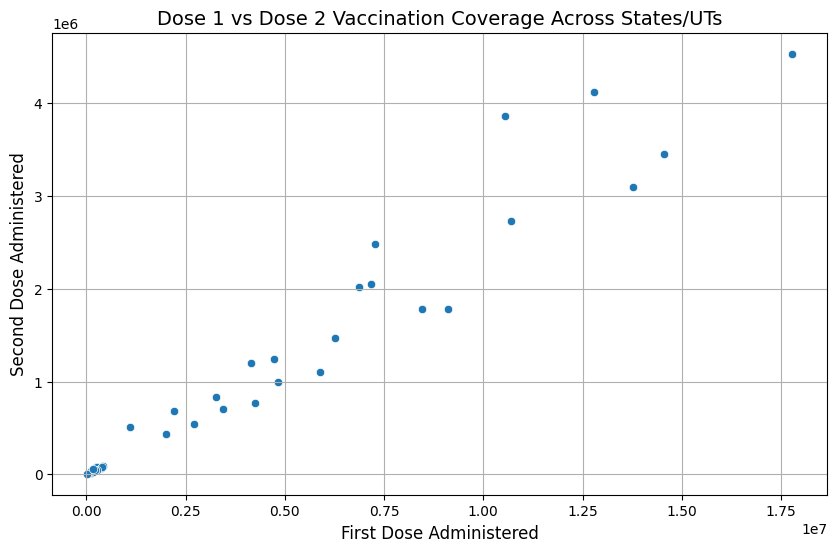

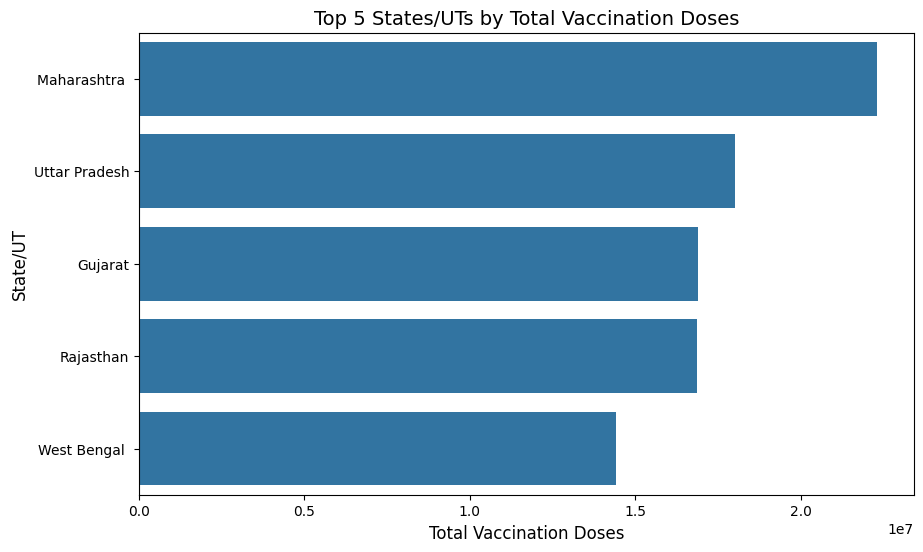

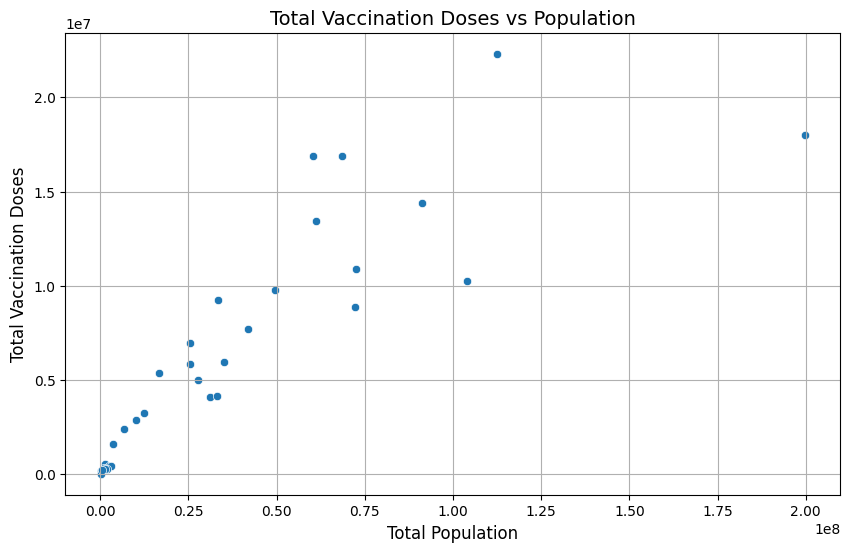

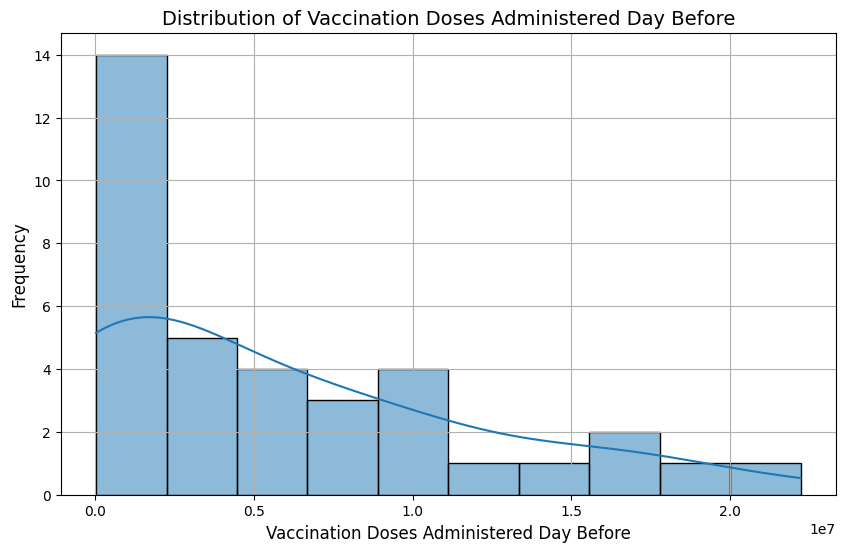

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualizing Dose 1 vs Dose 2 coverage
plt.figure(figsize=(10, 6))
sns.scatterplot(x='DOSE1', y='DOSE2', data=sheet1_data)
plt.title('Dose 1 vs Dose 2 Vaccination Coverage Across States/UTs', fontsize=14)
plt.xlabel('First Dose Administered', fontsize=12)
plt.ylabel('Second Dose Administered', fontsize=12)
plt.grid(True)
plt.show()

# 2. Top 5 states/UTs by total vaccination doses administered
top_5_vaccinations = sheet1_data.nlargest(5, 'TOTAL VACCINATION DOSES')
plt.figure(figsize=(10, 6))
sns.barplot(x='TOTAL VACCINATION DOSES', y='STATE/UTS', data=top_5_vaccinations)
plt.title('Top 5 States/UTs by Total Vaccination Doses', fontsize=14)
plt.xlabel('Total Vaccination Doses', fontsize=12)
plt.ylabel('State/UT', fontsize=12)
plt.show()

# 3. Visualizing Population vs. Total Vaccination Doses
plt.figure(figsize=(10, 6))
sns.scatterplot(x='TOTAL POPULATION', y='TOTAL VACCINATION DOSES', data=sheet1_data)
plt.title('Total Vaccination Doses vs Population', fontsize=14)
plt.xlabel('Total Population', fontsize=12)
plt.ylabel('Total Vaccination Doses', fontsize=12)
plt.grid(True)
plt.show()

# 4. Distribution of Vaccination Doses Administered the Day Before
plt.figure(figsize=(10, 6))
sns.histplot(sheet1_data['VACCINATION DOSES DAY BEFORE'], bins=10, kde=True)
plt.title('Distribution of Vaccination Doses Administered Day Before', fontsize=14)
plt.xlabel('Vaccination Doses Administered Day Before', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True)
plt.show()


                         TOTAL POPULATION  TOTAL VACCINATION DOSES
TOTAL POPULATION                 1.000000                 0.870848
TOTAL VACCINATION DOSES          0.870848                 1.000000


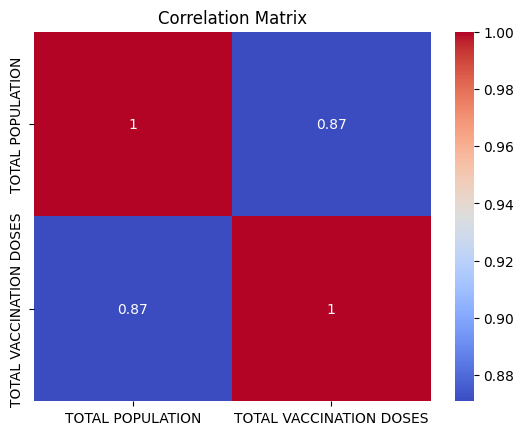

In [13]:
correlation_matrix = sheet1_data[['TOTAL POPULATION', 'TOTAL VACCINATION DOSES']].corr()
print(correlation_matrix)

# Plot the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [14]:
# 1. Vaccination Efficiency (Percentage of Population Vaccinated with Dose 1 and Dose 2)
sheet1_data['Dose1 Coverage (%)'] = (sheet1_data['DOSE1'] / sheet1_data['TOTAL POPULATION']) * 100
sheet1_data['Dose2 Coverage (%)'] = (sheet1_data['DOSE2'] / sheet1_data['TOTAL POPULATION']) * 100

# Sorting by Dose 1 coverage
top_dose1_coverage = sheet1_data.nlargest(5, 'Dose1 Coverage (%)')
bottom_dose1_coverage = sheet1_data.nsmallest(5, 'Dose1 Coverage (%)')

print("Top 5 States/UTs by Dose 1 Coverage (%):")
print(top_dose1_coverage[['STATE/UTS', 'Dose1 Coverage (%)']])

print("\nBottom 5 States/UTs by Dose 1 Coverage (%):")
print(bottom_dose1_coverage[['STATE/UTS', 'Dose1 Coverage (%)']])

# 2. States with Low Vaccination Coverage (Dose 1 or Dose 2)
low_vaccination_states = sheet1_data[(sheet1_data['Dose1 Coverage (%)'] < 20) | (sheet1_data['Dose2 Coverage (%)'] < 10)]
print("States with Low Vaccination Coverage (either Dose 1 < 20% or Dose 2 < 10%):")
print(low_vaccination_states[['STATE/UTS', 'Dose1 Coverage (%)', 'Dose2 Coverage (%)']])

# 3. Recent Vaccination Leaders (High Vaccination Doses Administered Day Before)
top_recent_vaccinations = sheet1_data.nlargest(5, 'VACCINATION DOSES DAY BEFORE')
print("\nTop 5 States/UTs by Vaccination Doses Administered the Day Before:")
print(top_recent_vaccinations[['STATE/UTS', 'VACCINATION DOSES DAY BEFORE']])

# 4. Ratio of Dose 1 to Dose 2
sheet1_data['Dose1/Dose2 Ratio'] = sheet1_data['DOSE1'] / sheet1_data['DOSE2']
top_dose1_dose2_gap = sheet1_data.nlargest(5, 'Dose1/Dose2 Ratio')
print("\nTop 5 States/UTs with the Highest Dose1/Dose2 Ratio (Largest Gap):")
print(top_dose1_dose2_gap[['STATE/UTS', 'Dose1/Dose2 Ratio']])


Top 5 States/UTs by Dose 1 Coverage (%):
       STATE/UTS  Dose1 Coverage (%)
17        Ladakh           42.647080
18  Lakshadweep            40.176508
32      Tripura            29.789459
9            Goa           29.437899
29       Sikkim            29.345848

Bottom 5 States/UTs by Dose 1 Coverage (%):
        STATE/UTS  Dose1 Coverage (%)
33  Uttar Pradesh            7.285980
4           Bihar            8.131899
30    Tamil Nadu             9.525926
14     Jharkhand            10.459819
3           Assam           10.462678
States with Low Vaccination Coverage (either Dose 1 < 20% or Dose 2 < 10%):
                                   STATE/UTS  Dose1 Coverage (%)  \
0                        Andaman and Nicobar           28.523757   
1                             Andhra Pradesh           14.688866   
2                          Arunachal Pradesh           18.408183   
3                                      Assam           10.462678   
4                                      Bihar    

# Key Insights from Vaccination Data Analysis

1. **Vaccination Dose 1 vs Dose 2 Coverage**:
   - There is a positive correlation between first and second doses administered across states. However, fewer second doses are given compared to first doses, indicating a gap in follow-up vaccinations.

2. **Top 5 States/UTs by Total Vaccinations**:
   - **Maharashtra** leads in total vaccinations, followed by **Uttar Pradesh**, **Gujarat**, **Rajasthan**, and **West Bengal**, largely due to their population size and effective vaccination campaigns.

3. **Population vs Vaccination Doses**:
   - Larger states like **Uttar Pradesh** and **Maharashtra** have administered the highest number of vaccines. Some medium-sized states, however, show better vaccine penetration relative to their population size.

4. **Vaccination Doses Administered the Day Before**:
   - Most states administered fewer than 1 million doses the day before the data was collected, with only a few states exceeding this number. This suggests variability in daily vaccination rates across different regions.

These insights highlight the positive correlation between population size and vaccination efforts but also emphasize the gap in second-dose coverage and uneven daily vaccination rates across states.
